In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path("benchmark/benchmark_results.csv")
df = pd.read_csv(CSV_PATH)
df.head()

,algorithm,vertex_count,edge_count,density_type,is_directed,is_weighted,reached_vertices,repetitions,average_time_microseconds
0,BFS,10,20,sparse,False,False,10,1000,0.903
1,DFS,10,20,sparse,False,False,10,1000,0.961
2,Dijkstra,10,20,sparse,False,False,10,1000,0.754
3,BFS,10,45,medium,False,False,10,1000,0.951
4,DFS,10,45,medium,False,False,10,1000,1.177


In [ ]:
# cleanup
df["is_directed"] = df["is_directed"].astype(bool)
df["is_weighted"] = df["is_weighted"].astype(bool)

# graph type labels
df["direction_type"] = df["is_directed"].map(
    {False: "Undirected", True: "Directed"})
df["weight_type"] = df["is_weighted"].map(
    {False: "Unweighted", True: "Weighted"})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   algorithm                  138 non-null    str    
 1   vertex_count               138 non-null    int64  
 2   edge_count                 138 non-null    int64  
 3   density_type               138 non-null    str    
 4   is_directed                138 non-null    bool   
 5   is_weighted                138 non-null    bool   
 6   reached_vertices           138 non-null    int64  
 7   repetitions                138 non-null    int64  
 8   average_time_microseconds  138 non-null    float64
 9   direction_type             138 non-null    str    
 10  weight_type                138 non-null    str    
dtypes: bool(2), float64(1), int64(4), str(4)
memory usage: 10.1 KB


### 1. Full Table

In [ ]:
df

,algorithm,vertex_count,edge_count,density_type,is_directed,is_weighted,reached_vertices,repetitions,average_time_microseconds,direction_type,weight_type
0,BFS,10,20,sparse,False,False,10,1000,0.903,Undirected,Unweighted
1,DFS,10,20,sparse,False,False,10,1000,0.961,Undirected,Unweighted
2,Dijkstra,10,20,sparse,False,False,10,1000,0.754,Undirected,Unweighted
3,BFS,10,45,medium,False,False,10,1000,0.951,Undirected,Unweighted
4,DFS,10,45,medium,False,False,10,1000,1.177,Undirected,Unweighted
...,...,...,...,...,...,...,...,...,...,...,...
133,DFS,1000,5000,medium,True,True,997,1000,12.000,Directed,Weighted
134,Dijkstra,1000,5000,medium,True,True,997,1000,57.247,Directed,Weighted
135,BFS,1000,10000,dense,True,True,999,1000,10.088,Directed,Weighted
136,DFS,1000,10000,dense,True,True,999,1000,24.997,Directed,Weighted


### 2. Avg Runtime by Vertex size

BFS, DFS, and Dijkstra as the size of vertices increases.

uses:

- undirected graphs
- weighted graphs
- dense graphs


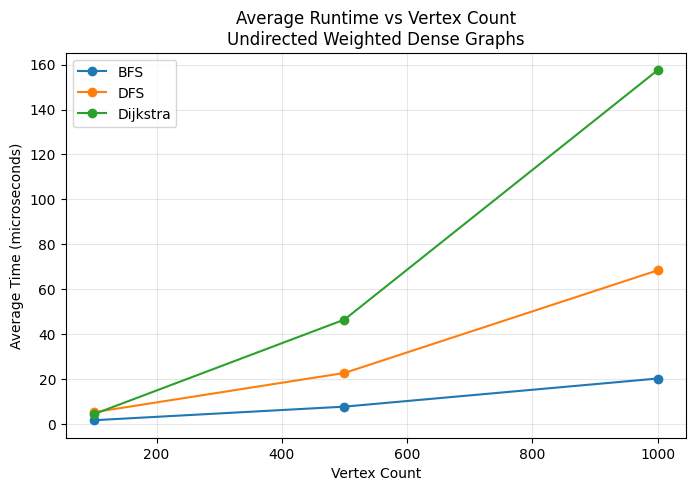

In [ ]:
plot_df = df[
    (df["direction_type"] == "Undirected") &
    (df["weight_type"] == "Weighted") &
    (df["density_type"] == "dense")
]

plt.figure(figsize=(8, 5))

for algorithm in plot_df["algorithm"].unique():
    alg_df = plot_df[plot_df["algorithm"] == algorithm]
    plt.plot(
        alg_df["vertex_count"],
        alg_df["average_time_microseconds"],
        marker="o",
        label=algorithm
    )

plt.title("Average Runtime vs Vertex Count\nUndirected Weighted Dense Graphs")
plt.xlabel("Vertex Count")
plt.ylabel("Average Time (microseconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 3. Effect of Graph Density

Plot shows how sparse, medium, and dense graphs affect runtime.

it uses:

- vertex count = 1000
- undirected graphs
- weighted graphs


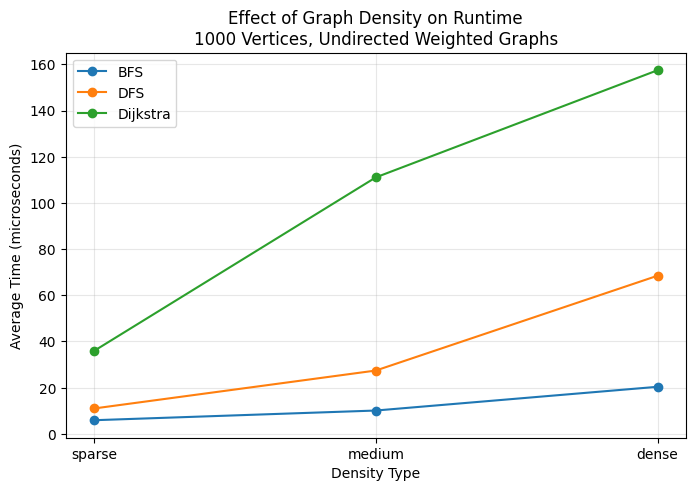

In [ ]:
plot_df = df[
    (df["vertex_count"] == 1000) &
    (df["direction_type"] == "Undirected") &
    (df["weight_type"] == "Weighted")
].copy()

density_order = ["sparse", "medium", "dense"]
plot_df["density_type"] = pd.Categorical(
    plot_df["density_type"],
    categories=density_order,
    ordered=True
)
plot_df = plot_df.sort_values("density_type")

plt.figure(figsize=(8, 5))

for algorithm in plot_df["algorithm"].unique():
    alg_df = plot_df[plot_df["algorithm"] == algorithm]
    plt.plot(
        alg_df["density_type"].astype(str),
        alg_df["average_time_microseconds"],
        marker="o",
        label=algorithm
    )

plt.title("Effect of Graph Density on Runtime\n1000 Vertices, Undirected Weighted Graphs")
plt.xlabel("Density Type")
plt.ylabel("Average Time (microseconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4. Directed vs Undirected Comparison

This plot compares directed and undirected graphs.

To keep the plot readable, it uses:

- vertex count = 1000
- weighted graphs
- dense graphs


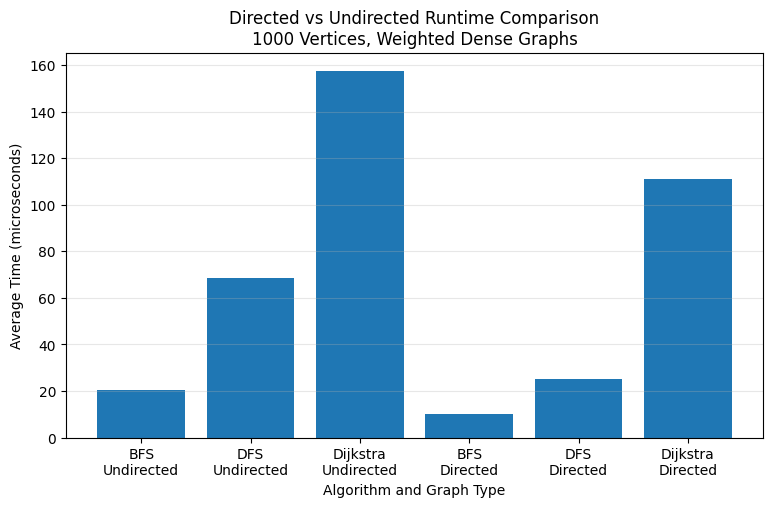

In [ ]:
plot_df = df[
    (df["vertex_count"] == 1000) &
    (df["weight_type"] == "Weighted") &
    (df["density_type"] == "dense")
].copy()

algorithms = ["BFS", "DFS", "Dijkstra"]

x_labels = []
values = []

for direction_type in ["Undirected", "Directed"]:
    for algorithm in algorithms:
        row = plot_df[
            (plot_df["direction_type"] == direction_type) &
            (plot_df["algorithm"] == algorithm)
        ]
        if not row.empty:
            x_labels.append(f"{algorithm}\n{direction_type}")
            values.append(row["average_time_microseconds"].iloc[0])

plt.figure(figsize=(9, 5))
plt.bar(x_labels, values)
plt.title("Directed vs Undirected Runtime Comparison\n1000 Vertices, Weighted Dense Graphs")
plt.xlabel("Algorithm and Graph Type")
plt.ylabel("Average Time (microseconds)")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 5. Reachable Vertices

BFS, DFS, and Dijkstra start from vertex = 0.

For the sparse directed graphs, vertex = 0 may not be able to reach all other vertices. 
this is why reachable vertex count can be much smaller than the total vertex count.


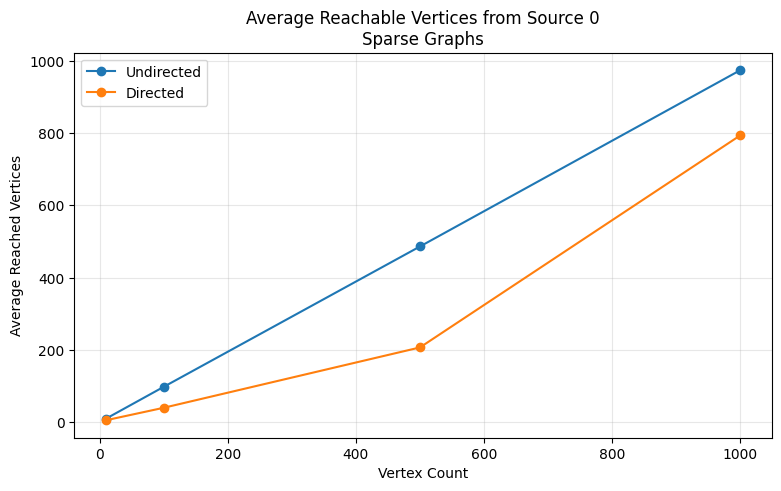

In [ ]:
plot_df = df[
    (df["algorithm"] == "BFS") &
    (df["density_type"] == "sparse")
].copy()

plt.figure(figsize=(9, 5))

for direction_type in plot_df["direction_type"].unique():
    sub_df = plot_df[plot_df["direction_type"] == direction_type]
    grouped = sub_df.groupby("vertex_count")["reached_vertices"].mean()
    plt.plot(
        grouped.index,
        grouped.values,
        marker="o",
        label=direction_type
    )

plt.title("Average Reachable Vertices from Source 0\nSparse Graphs")
plt.xlabel("Vertex Count")
plt.ylabel("Average Reached Vertices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
